# Quantile Regression for Antarctic AR Project

An analysis in `R` to do quantile regression on Antarctic ARs. Preliminary statistical results for the project.

Author: Jimmy Butler

Date: November 2024

In [6]:
library(erf)
library(grf)
library(quantreg)
library(dplyr)
library(latex2exp)
library(ggplot2)
library(cowplot)

options(warn=-1)

Loading required package: SparseM


Attaching package: ‘SparseM’


The following object is masked from ‘package:base’:

    backsolve



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [7]:
catalog <- read.csv('/global/homes/j/jbbutler/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts10/landfalling_df_no_da.csv')
covariates <- catalog %>% select('cumulative_landfalling_area', 'max_south_extent', 'max_landfalling_v850hPa', 'max_IWV_ais', 'max_ocean_SLP_gradient')
impact_vars <- catalog %>% select('max_T2M_anomaly_ais', 'cumulative_rainfall_ais', 'cumulative_snowfall_ais', 'max_T2m_ais')


In [17]:
rand_split <- sample(1:nrow(impact_vars), nrow(impact_vars)*0.8, replace=FALSE)
train_X <- covariates[rand_split,]
train_Y <- impact_vars[rand_split,]

In [34]:
q.forest <- quantile_forest(train_X[,3:5], train_Y[,3], quantiles = c(0.9))

In [35]:
variable_importance(q.forest)

0.20272046
0.70516435
0.09211519


In [29]:
train_X

,cumulative_landfalling_area,max_south_extent,max_landfalling_v850hPa,max_IWV_ais,max_ocean_SLP_gradient
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2915,379004.2199,-74.5,31.065098,9.994593,6.444256
690,64605.1555,-75.5,36.285805,10.619961,8.109375
1754,135693.0692,-80.0,27.097839,11.344548,4.590636
1743,435755.0689,-85.0,30.189579,10.179338,2.517924
906,1663.5964,-71.0,33.091621,10.708237,3.739913
1557,13198.9863,-72.5,29.975151,14.805893,4.742215
2605,143809.9189,-78.0,7.450212,12.089493,1.459290
1462,688.7653,-77.0,24.370636,8.400776,4.733450
480,1034412.5945,-81.0,32.201183,14.691725,4.410769


## Setup

In [50]:
catalog = read.csv('/global/homes/j/jbbutler/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts10/landfalling_df_no_da.csv')
covariates = catalog %>% select('cumulative_landfalling_area', 'max_south_extent', 'max_landfalling_v850hPa', 'max_IWV_ais', 'max_ocean_SLP_gradient')
impact_vars = catalog %>% select('max_T2M_anomaly_ais', 'cumulative_rainfall_ais', 'cumulative_snowfall_ais', 'max_T2m_ais')

standardize <- function(col) {
    return((col - mean(col))/sd(col))
}

standardized_impacts = apply(impact_vars, 2, standardize)
standardized_covariates = apply(covariates, 2, standardize)

standardized_dataset = data.frame(cbind(standardized_impacts, standardized_covariates))
standardized_dataset = standardized_dataset %>% mutate(region = catalog$coarser_region)
dataset <- data.frame(cbind(impact_vars, covariates))

## Non-Extremal Quantile Regression

### Assumptions

Let $Y_{i} \in \mathbb{R}$ be the outcomes and let the covariates be $X_{i} \in \mathbb{R}^{d}$. Assume a fixed set of covariates. Suppose the $Y_{i}$ are independent, with distribution functions $F_{i}$, and that conditional quantile function is linear in the covariates, i.e.:
$$
Q_{Y_{i}}(\tau | X_{i}) = X_{i}'\beta(\tau)
$$

Let $F_{Y_{i}|X_{i}}$ denote the conditional cdf of $Y_{i}$ given $X_{i}$. Suppose the following:

+ The $F_{Y_{i}|X_{i}}$ are absolutely continuous, and admit continuous densities $f_{i}$ that are bounded away from 0 and $\infty$ at the $\tau$ quantiles $Q_{Y_{i}}(\tau | X_{i})$.
+ There exists a positive definite matrix $D_{0}$ for which $D_{0} = \lim_{n \to \infty} \frac{1}{n}\sum_{i=1}^{n}X_{i}X_{i}'$
+ There exists a positive definite matrix $D_{1}$ for which $D_{1} = \lim_{n \to \infty} \frac{1}{n} \sum_{i=1}^{n} f_{i}(Q_{Y_{i}}(\tau | X_{i}))X_{i}X_{i}'$


According to Koenker (2005), the standard quantile regression estimator for the $\tau$ quantile, $\hat{\beta}(\tau)$ satisfies the following weak convergence statement:
$$
\sqrt{n}(\hat{\beta}(\tau) - \beta(\tau)) \implies \mathcal{N}(0, \tau(1-\tau)D_{1}^{-1}D_{0}D_{1}^{-1})
$$

where

$$
D_{0} = \lim_{n \to \infty} \frac{1}{n}\sum_{i=1}^{n}X_{i}X_{i}', D_{1} = \lim_{n \to \infty} \frac{1}{n} \sum_{i=1}^{n} f_{i}(Q_{Y_{i}}(\tau | X_{i}))X_{i}X_{i}'
$$ 


### 2m-Temperature Anomaly Results

In [103]:
alpha <- 0.05
taus <- c(0.9, 0.99)
n_taus <- length(taus)
coefficients <- vector(mode='list', length = n_taus)
for (i in 1:length(taus)) {
    
    tau <- taus[i]
    qr_fit <- rq(max_T2M_anomaly_ais ~ max_landfalling_v850hPa + max_IWV_ais, tau=tau, data=standardized_dataset)
    coefficients[[i]] <- qr_fit$coefficients
    
}

In [104]:
coefficients

[[1]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
             1.35851566              0.19305179              0.02926289 

[[2]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
              2.3668934               0.1374446               0.2605150

In [105]:
alpha <- 0.05
taus <- c(0.9, 0.99)
n_taus <- length(taus)
coefficients <- vector(mode='list', length = n_taus)
for (i in 1:length(taus)) {
    
    tau <- taus[i]
    qr_fit <- rq(cumulative_snowfall_ais ~ max_landfalling_v850hPa + max_IWV_ais, tau=tau, data=standardized_dataset)
    coefficients[[i]] <- qr_fit$coefficients
    
}

In [106]:
coefficients

[[1]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
             1.05582545              0.04356242              0.88654182 

[[2]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
             2.74920908              0.07969022              1.33202227

### West

In [107]:
alpha <- 0.05
taus <- c(0.5, 0.9, 0.99)
n_taus <- length(taus)
coefficients <- vector(mode='list', length = n_taus)
regional_dataset <- standardized_dataset %>% filter(region=='West')
for (i in 1:length(taus)) {
    tau <- taus[i]
    qr_fit <- rq(max_T2M_anomaly_ais ~ max_landfalling_v850hPa + max_IWV_ais, tau=tau, data=regional_dataset)
    coefficients[[i]] <- qr_fit$coefficients  
}

coefficients

[[1]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
              0.2582817               0.4599030              -0.2520685 

[[2]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
              1.4849578               0.4121390              -0.2266007 

[[3]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
              2.3151511               0.4949592              -0.2249142

In [108]:
alpha <- 0.05
taus <- c(0.5, 0.9, 0.99)
n_taus <- length(taus)
coefficients <- vector(mode='list', length = n_taus)
regional_dataset <- standardized_dataset %>% filter(region=='West')
for (i in 1:length(taus)) {
    tau <- taus[i]
    qr_fit <- rq(cumulative_snowfall_ais ~ max_landfalling_v850hPa + max_IWV_ais, tau=tau, data=regional_dataset)
    coefficients[[i]] <- qr_fit$coefficients  
}

coefficients

[[1]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
             -0.3665461               0.1932239               0.2333206 

[[2]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
              0.7527932               0.4568476               0.7638408 

[[3]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
              2.0362435               0.1460248               1.3241683

### East 1

In [109]:
alpha <- 0.05
taus <- c(0.5, 0.9, 0.99)
n_taus <- length(taus)
coefficients <- vector(mode='list', length = n_taus)
regional_dataset <- standardized_dataset %>% filter(region=='East 1')
for (i in 1:length(taus)) {
    tau <- taus[i]
    qr_fit <- rq(max_T2M_anomaly_ais ~ max_landfalling_v850hPa + max_IWV_ais, tau=tau, data=regional_dataset)
    coefficients[[i]] <- qr_fit$coefficients
}

coefficients

[[1]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
            -0.16440144              0.12827547              0.05204488 

[[2]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
              1.2486609               0.1437370               0.2029352 

[[3]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
            2.083301489             0.250568670            -0.003114542

In [110]:
alpha <- 0.05
taus <- c(0.5, 0.9, 0.99)
n_taus <- length(taus)
coefficients <- vector(mode='list', length = n_taus)
regional_dataset <- standardized_dataset %>% filter(region=='East 1')
for (i in 1:length(taus)) {
    tau <- taus[i]
    qr_fit <- rq(cumulative_snowfall_ais ~ max_landfalling_v850hPa + max_IWV_ais, tau=tau, data=regional_dataset)
    coefficients[[i]] <- qr_fit$coefficients  
}

coefficients

[[1]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
             0.01877055              0.09755778              0.49006565 

[[2]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
             1.37638675              0.01894613              1.11386201 

[[3]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
             2.91230220              0.03877297              1.46251468

### East 2

In [111]:
alpha <- 0.05
taus <- c(0.5, 0.9, 0.99)
n_taus <- length(taus)
coefficients <- vector(mode='list', length = n_taus)
regional_dataset <- standardized_dataset %>% filter(region=='East 2')
for (i in 1:length(taus)) {
    tau <- taus[i]
    qr_fit <- rq(max_T2M_anomaly_ais ~ max_landfalling_v850hPa + max_IWV_ais, tau=tau, data=regional_dataset)
    coefficients[[i]] <- qr_fit$coefficients  
}

coefficients

[[1]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
            -0.13366235              0.14809394              0.03078775 

[[2]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
            1.482714742            -0.002168029             0.507471881 

[[3]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
              2.5138472               0.1081348               0.3467841

In [112]:
alpha <- 0.05
taus <- c(0.5, 0.9, 0.99)
n_taus <- length(taus)
coefficients <- vector(mode='list', length = n_taus)
regional_dataset <- standardized_dataset %>% filter(region=='East 2')
for (i in 1:length(taus)) {
    tau <- taus[i]
    qr_fit <- rq(cumulative_snowfall_ais ~ max_landfalling_v850hPa + max_IWV_ais, tau=tau, data=regional_dataset)
    coefficients[[i]] <- qr_fit$coefficients  
}

coefficients

[[1]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
             -0.1749443               0.0468321               0.3893446 

[[2]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
              1.1282590              -0.0275014               1.0010488 

[[3]]
            (Intercept) max_landfalling_v850hPa             max_IWV_ais 
              2.8468809              -0.1445908               1.6936335

In [113]:
alpha <- 0.05
taus <- c(0.9, 0.99)
n_taus <- length(taus)
ci_lowers <- vector(mode='list', length = n_taus)
ci_uppers <- vector(mode='list', length = n_taus)
for (i in 1:length(taus)) {
    
    tau <- taus[i]
    qr_fit <- rq(max_T2M_anomaly_ais ~ cumulative_landfalling_area + max_south_extent + max_landfalling_v850hPa + max_IWV_ais + max_ocean_SLP_gradient, tau=tau, data=standardized_dataset)
    
    if (taus[i] <= 0.9) {
        ses <- summary(qr_fit, se='ker')$coefficients[,2]
        ests <- summary(qr_fit, se='ker')$coefficients[,1]
        ci_lowers[[i]] <- ests + qnorm(alpha/2)*ses
        ci_uppers[[i]] <- ests + qnorm(1-(alpha/2))*ses
        }
    else {
        
        qr_fit_summary <- summary(qr_fit, se='extreme', alpha=0.05)
        ci_lowers[[i]] <- -qr_fit_summary$coefficients[-1,3]
        ci_uppers[[i]] <- -qr_fit_summary$coefficients[-1,4]
        
    }
    
}

In [4]:
ci_lowers <- data.frame(do.call(rbind, ci_lowers))
ci_uppers <- data.frame(do.call(rbind, ci_uppers))

ci_lowers$taus <- taus
ci_uppers$taus <- taus

full_df <- data.frame(cbind(ci_uppers, ci_lowers))

In [5]:
ci_lowers

X.Intercept.,cumulative_landfalling_area,max_south_extent,max_landfalling_v850hPa,max_IWV_ais,max_ocean_SLP_gradient,taus
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.8822456,0.1619735,-0.7037265,0.06803241,-0.1728944,-0.06138833,0.90
-0.6099689,-0.7205754,-0.5779625,-0.68939573,-0.4789548,-0.60996888,0.99


In [6]:
ci_uppers

X.Intercept.,cumulative_landfalling_area,max_south_extent,max_landfalling_v850hPa,max_IWV_ais,max_ocean_SLP_gradient,taus
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.9670775,0.3365952,-0.5920708,0.1676539,-0.05423448,0.02459748,0.90
1.5324687,1.3164445,1.6098988,1.3071442,1.42867818,1.53246871,0.99


In [42]:
library(tidyr)
ci_df <- gather(ci_lowers[,c(-1,-7)], coefficient, lower)
ci_df$upper <- gather(ci_uppers[,c(-1,-7)], coefficient, uppers)$uppers
ci_df$taus <- as.factor(rep(taus, 5))
ci_df$coefficient <- as.factor(ci_df$coefficient)

In [43]:
options(repr.plot.width=8, repr.plot.height=6)

plt <- ggplot(data=ci_df) + geom_errorbar(aes(x=coefficient, ymin=lower, ymax=upper, color=taus), width=0.2, position=position_dodge(width=0.3), linewidth=1) + 
geom_hline(yintercept=0, color='black', linetype='dotted', linewidth=1.5) + ggtitle('95% Confidence Intervals, T Anomaly Coefficients') +
#ylim(c(-0.75, 0.6)) +
ylab('Coefficient Value') +
xlab('') +
coord_cartesian(ylim=c(-0.75, 0.6), expand=0) +
scale_x_discrete(labels=c(TeX('$\\beta_{CLA}$'), TeX('$\\beta_{SLP}$'), TeX('$\\beta_{IWV}$'), TeX('$\\beta_{South}$'), TeX('$\\beta_{V10m}'))) +
theme_light() +
theme(legend.title=element_blank(), legend.position=c(0.15,0.15), 
      legend.background=element_blank(), axis.text.x=element_text(size=15), axis.text.y=element_text(size=15),
     axis.title.x=element_text(size=15), axis.title.y=element_text(size=15), plot.title = element_text(size=18),
     legend.text=element_text(size=15))

ggsave('t_anomaly_coefficients.png', plt, width=8, height=6)

#### Aside: Bug in Quantile Regression Package

Clearly, the regression coefficient for the $\tau$ quantile of the negated outcome distribution should be equal to the negative of the $1-\tau$ quantile of the original outcome distribution. So, to get a CI for the $1-\tau$ quantile of the original distribution, we should be able to take the $\tau$ quantiles CI and negate the bounds. This is not the case..

In [35]:
negated_dataset <- standardized_dataset
negated_dataset$cumulative_snowfall_ais <- -standardized_dataset$cumulative_snowfall_ais

qr_fit <- rq(cumulative_snowfall_ais ~ cumulative_landfalling_area, tau=0.01, data=negated_dataset)
summary(qr_fit, se='extreme', alpha=0.05)


Call: rq(formula = cumulative_snowfall_ais ~ cumulative_landfalling_area, 
    tau = 0.01, data = negated_dataset)

tau: [1] 0.01

Coefficients:
                            coef     BCcoef   ciL      ciU     
(Intercept)                 -1.04445 -1.29669 -1.72849 -1.11045
cumulative_landfalling_area -1.88136 -1.83673 -2.17883 -1.60720

In [53]:
colnames(standardized_dataset)

[1] "max_T2M_anomaly_ais"         "cumulative_rainfall_ais"    
[3] "cumulative_snowfall_ais"     "max_T2m_ais"                
[5] "cumulative_landfalling_area" "max_south_extent"           
[7] "max_V10m_ais"                "max_IWV_ais"                
[9] "landfalling_SLP"

In [55]:
qr_fit <- rq(cumulative_snowfall_ais ~ cumulative_landfalling_area, tau=0.99, data=standardized_dataset)
summary(qr_fit, se='extreme', alpha=0.05)


Call: rq(formula = cumulative_snowfall_ais ~ cumulative_landfalling_area, 
    tau = 0.99, data = standardized_dataset)

tau: [1] 0.99

Coefficients:
                            coef     BCcoef   ciL      ciU     
(Intercept)                  1.04445 -1.26868 -1.09738 -1.68748
cumulative_landfalling_area  1.88136 -1.84208 -1.63706 -2.13198

In [56]:
qr_fit <- rq(cumulative_snowfall_ais ~ max_south_extent, tau=0.99, data=standardized_dataset)
summary(qr_fit, se='extreme', alpha=0.05)


Call: rq(formula = cumulative_snowfall_ais ~ max_south_extent, tau = 0.99, 
    data = standardized_dataset)

tau: [1] 0.99

Coefficients:
                 coef     BCcoef   ciL      ciU     
(Intercept)       2.51326 -1.69302  4.20352 -5.49287
max_south_extent -1.61039  0.36732  2.82941 -6.47611

In [57]:
qr_fit <- rq(cumulative_snowfall_ais ~ max_V10m_ais, tau=0.99, data=standardized_dataset)
summary(qr_fit, se='extreme', alpha=0.05)


Call: rq(formula = cumulative_snowfall_ais ~ max_V10m_ais, tau = 0.99, 
    data = standardized_dataset)

tau: [1] 0.99

Coefficients:
             coef     BCcoef   ciL      ciU     
(Intercept)   2.63854 -3.21220 -2.60839 -4.82550
max_V10m_ais  1.66731 -2.52533 -1.89530 -4.09992

In [58]:
qr_fit <- rq(cumulative_snowfall_ais ~ max_IWV_ais, tau=0.99, data=standardized_dataset)
summary(qr_fit, se='extreme', alpha=0.05)


Call: rq(formula = cumulative_snowfall_ais ~ max_IWV_ais, tau = 0.99, 
    data = standardized_dataset)

tau: [1] 0.99

Coefficients:
            coef     BCcoef   ciL      ciU     
(Intercept)  2.73597 -3.10435 -2.61454 -4.64465
max_IWV_ais  1.62506 -2.47886 -1.86990 -4.31075

In [59]:
qr_fit <- rq(cumulative_snowfall_ais ~ landfalling_SLP, tau=0.99, data=standardized_dataset)
summary(qr_fit, se='extreme', alpha=0.05)


Call: rq(formula = cumulative_snowfall_ais ~ landfalling_SLP, tau = 0.99, 
    data = standardized_dataset)

tau: [1] 0.99

Coefficients:
                coef     BCcoef   ciL      ciU     
(Intercept)      3.70493 -3.54444 -1.16820 -6.38069
landfalling_SLP -0.08824 -1.26644  0.20204 -5.79336

## Cumulative Snowfall Results

In [19]:
alpha <- 0.05
taus <- c(0.9, 0.99, 0.999)
n_taus <- length(taus)
ci_lowers <- vector(mode='list', length = n_taus)
ci_uppers <- vector(mode='list', length = n_taus)
for (i in 1:length(taus)) {
    
    tau <- taus[i]
    qr_fit <- rq(cumulative_snowfall_ais ~ cumulative_landfalling_area + max_south_extent + max_landfalling_v850hPa + max_IWV_ais + max_ocean_SLP_gradient, tau=tau, data=standardized_dataset)
    
    if (taus[i] <= 0.9) {
        ses <- summary(qr_fit, se='ker')$coefficients[,2]
        ests <- summary(qr_fit, se='ker')$coefficients[,1]
        ci_lowers[[i]] <- ests + qnorm(alpha/2)*ses
        ci_uppers[[i]] <- ests + qnorm(1-(alpha/2))*ses
        }
    else {
        
        qr_fit_summary <- summary(qr_fit, se='extreme', alpha=0.05)
        ci_lowers[[i]] <- -qr_fit_summary$coefficients[-1,3]
        ci_uppers[[i]] <- -qr_fit_summary$coefficients[-1,4]
        
    }
    
}

In [20]:
ci_lowers <- data.frame(do.call(rbind, ci_lowers))
ci_uppers <- data.frame(do.call(rbind, ci_uppers))

ci_lowers$taus <- taus
ci_uppers$taus <- taus

full_df <- data.frame(cbind(ci_uppers, ci_lowers))

In [21]:
ci_lowers

X.Intercept.,cumulative_landfalling_area,max_south_extent,max_landfalling_v850hPa,max_IWV_ais,max_ocean_SLP_gradient,taus
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.4297844,1.04299950,-0.1042729,0.0321642,0.1943295,-0.03803889,0.900
0.1106169,-0.05596156,-0.0591245,0.0255861,-0.0885673,0.11061690,0.990
-2.1313163,0.03493762,-0.3807927,-0.4116651,-0.3044907,-2.13131629,0.999


In [22]:
ci_uppers

X.Intercept.,cumulative_landfalling_area,max_south_extent,max_landfalling_v850hPa,max_IWV_ais,max_ocean_SLP_gradient,taus
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.4872177,1.264837,-0.04513984,0.08031965,0.2653211,0.002606446,0.900
1.6585251,1.232249,1.45770984,1.18571045,1.1826535,1.658525064,0.990
1.8024937,3.624388,2.85518203,2.97208587,3.0328033,1.802493668,0.999


In [10]:
library(tidyr)
ci_df <- gather(ci_lowers[,c(-1,-7)], coefficient, lower)
ci_df$upper <- gather(ci_uppers[,c(-1,-7)], coefficient, uppers)$uppers
ci_df$taus <- as.factor(rep(taus, 5))
ci_df$coefficient <- as.factor(ci_df$coefficient)

In [11]:
options(repr.plot.width=8, repr.plot.height=4)

plt <- ggplot(data=ci_df) + geom_errorbar(aes(x=coefficient, ymin=lower, ymax=upper, color=taus), width=0.2, position=position_dodge(width=0.3), linewidth=1) + 
geom_hline(yintercept=0, color='black', linetype='dotted', linewidth=1.5) + ggtitle('95% Confidence Intervals, Snow Coefficients') +
#ylim(c(-0.75, 0.6)) +
ylab('Coefficient Value') +
xlab('') +
coord_cartesian(ylim=c(-0.5, 1.2), expand=0) +
scale_x_discrete(labels=c(TeX('$\\beta_{CLA}$'), TeX('$\\beta_{SLP}$'), TeX('$\\beta_{IWV}$'), TeX('$\\beta_{South}$'), TeX('$\\beta_{V10m}'))) +
theme_light() +
theme(legend.title=element_blank(), legend.position=c(0.15,0.15), 
      legend.background=element_blank(), axis.text.x=element_text(size=15), axis.text.y=element_text(size=15),
     axis.title.x=element_text(size=15), axis.title.y=element_text(size=15), plot.title = element_text(size=18),
     legend.text=element_text(size=15))

ggsave('snow_coefficients.png', plt, width=8, height=6)

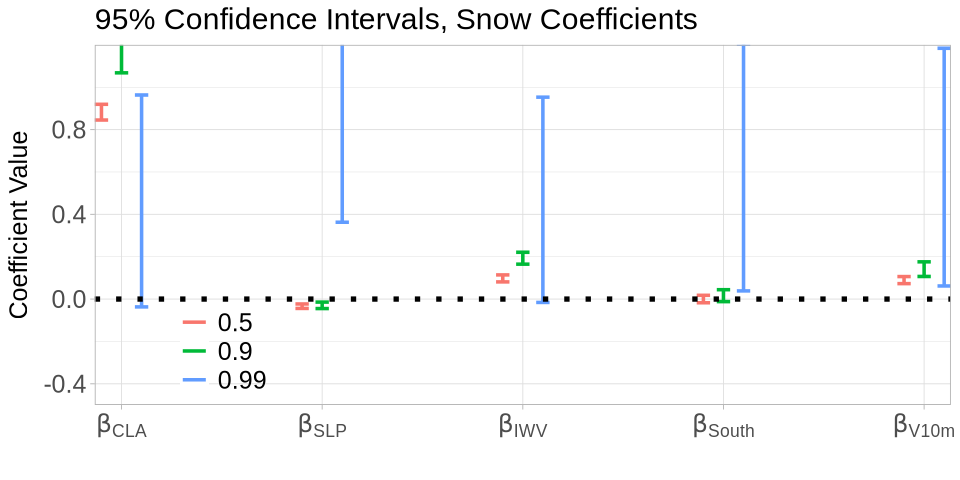

In [12]:
plt

In [16]:
qr_fit <- rq(cumulative_snowfall_ais ~ cumulative_landfalling_area + max_south_extent + max_V10m_ais + max_IWV_ais + landfalling_SLP, tau=0.99, data=standardized_dataset)
qr_fit_summary <- summary(qr_fit, se='extreme', alpha=0.05)
qr_fit_summary


Call: rq(formula = cumulative_snowfall_ais ~ cumulative_landfalling_area + 
    max_south_extent + max_V10m_ais + max_IWV_ais + landfalling_SLP, 
    tau = 0.99, data = standardized_dataset)

tau: [1] 0.99

Coefficients:
                            coef     BCcoef   ciL      ciU     
(Intercept)                  0.87710 -0.68261 -0.39227 -1.55884
cumulative_landfalling_area  1.35380 -0.81554 -0.42075 -1.57381
max_south_extent             0.01956 -0.14330  0.02583 -0.98472
max_V10m_ais                 0.18944 -0.23447 -0.04104 -1.22349
max_IWV_ais                  0.27074 -0.28081 -0.10813 -1.17784
landfalling_SLP             -0.00705 -0.14473  0.01462 -1.01266

In [114]:
ylims <- c(-0.7, 0.7)
ax_title_fsize <- 18
axis_fsize <- 18
title_fsize <- 18

cla_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=cumulative_landfalling_area), color='blue') + 
geom_line(aes(x=taus, y=cumulative_landfalling_area.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=cumulative_landfalling_area.1,ymax=cumulative_landfalling_area), fill="cyan", alpha = 0.1) +
ylim(ylims) + 
geom_hline(yintercept=0, linetype='dashed') + 
xlab('Percentile') + 
ylab(TeX('$\\beta_{CLA}$')) + ggtitle('Cumulative Landfalling Area') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

south_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_south_extent), color='blue') + 
geom_line(aes(x=taus, y=max_south_extent.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_south_extent.1,ymax=max_south_extent), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{south}$')) + ggtitle('Max Southward Extent') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

v10m_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_V10m_ais), color='blue') + 
geom_line(aes(x=taus, y=max_V10m_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_V10m_ais.1,ymax=max_V10m_ais), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{v10m}$')) + ggtitle('Max v10m over AIS') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

iwv_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_IWV_ais), color='blue') + 
geom_line(aes(x=taus, y=max_IWV_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_IWV_ais.1,ymax=max_IWV_ais), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{IWV}$')) + ggtitle('Max IWV') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

slp_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=landfalling_SLP.1), color='blue') + 
geom_line(aes(x=taus, y=landfalling_SLP), color='blue') + 
geom_ribbon(aes(x=taus, ymin=landfalling_SLP.1,ymax=landfalling_SLP), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{SLP}$')) + ggtitle('Landfalling SLP') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))


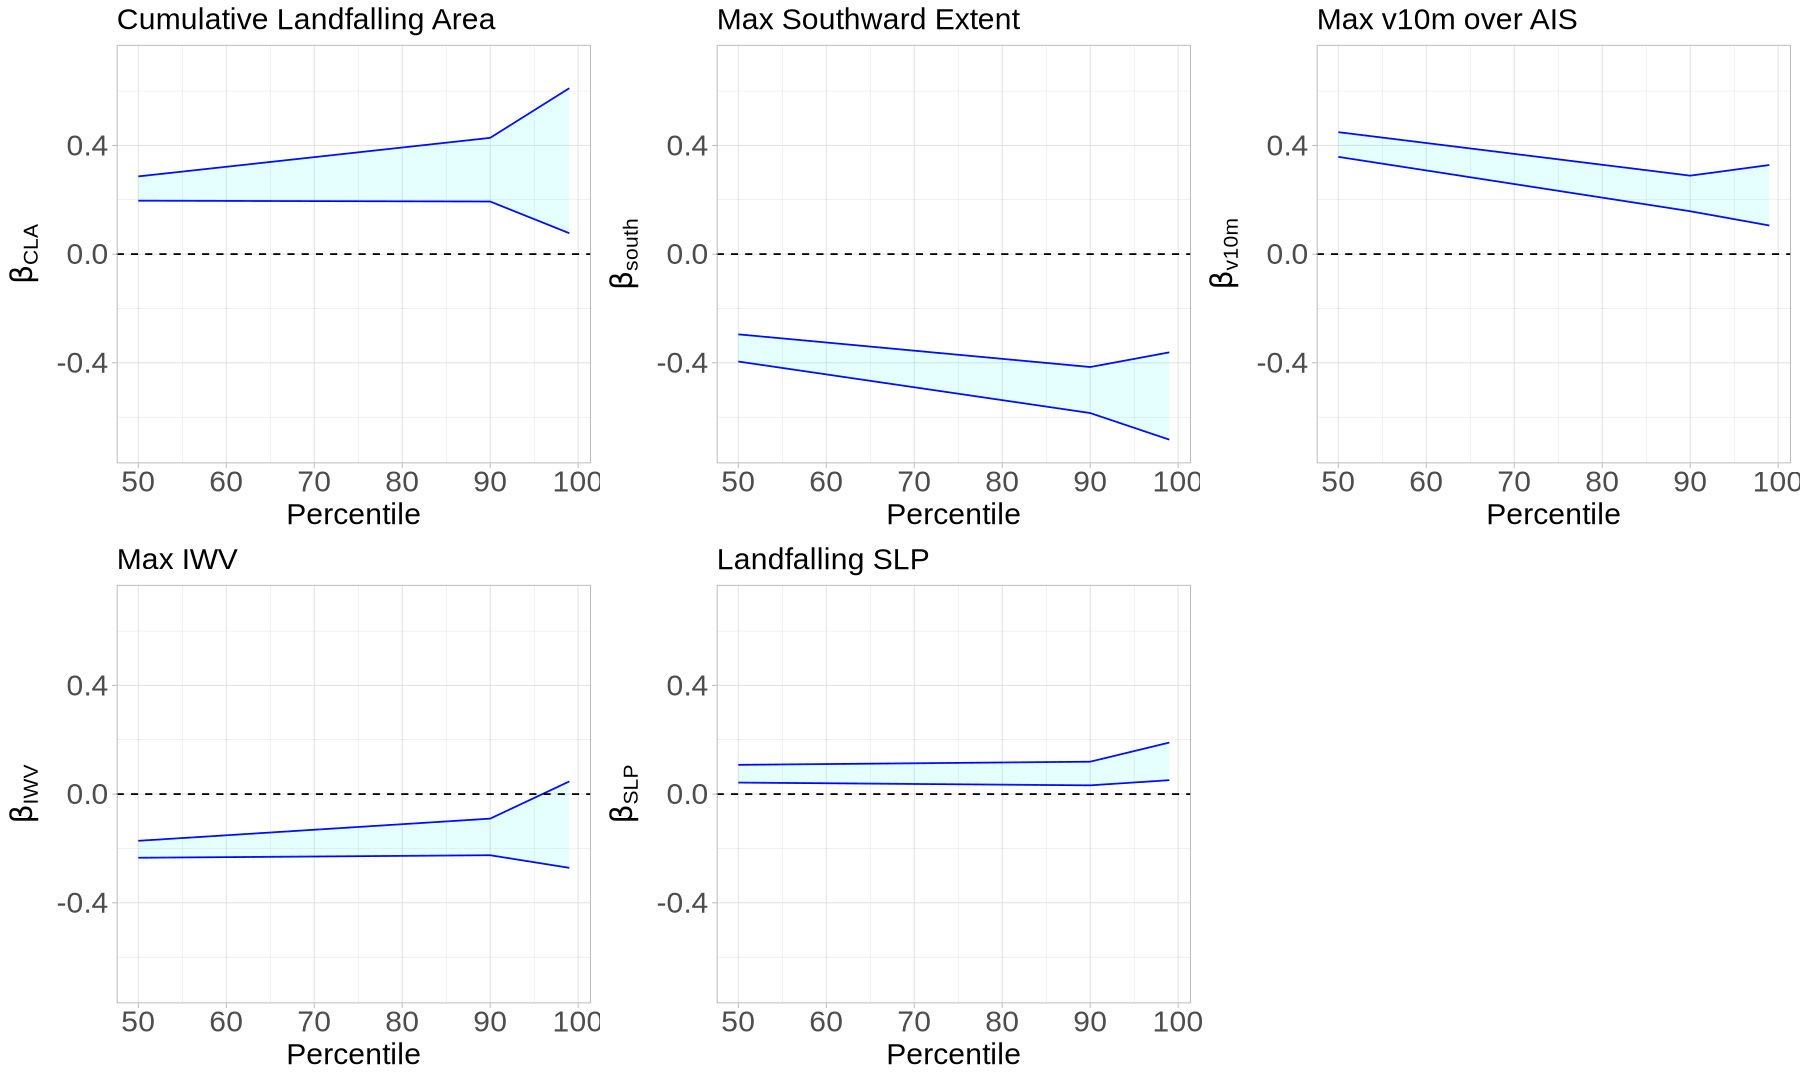

In [20]:
options(repr.plot.width=15, repr.plot.height=9)
p = cowplot::plot_grid(cla_plt, south_plt, v10m_plt, iwv_plt, slp_plt,
                   ncol = 3)
#ggsave('~/isolines_uq/plots/karachi_base_cov_log.png', p, height=7, width=21)
p

### 2m-Temperature Absolute Results

In [7]:
n_taus <- 100
alpha <- 0.05
taus <- seq(0.5, 0.99, length.out=n_taus)
ci_lowers <- vector(mode='list', length = n_taus)
ci_uppers <- vector(mode='list', length = n_taus)
for (i in 1:length(taus)) {
    
    tau <- taus[i]
    qr_fit <- rq(max_T2m_ais ~ cumulative_landfalling_area + max_south_extent + max_V10m_ais + max_IWV_ais + landfalling_SLP, tau=tau, data=standardized_dataset)
    ses <- summary(qr_fit)$coefficients[,2]
    ests <- summary(qr_fit)$coefficients[,1]
    ci_lowers[[i]] <- ests + qnorm(alpha/2)*ses
    ci_uppers[[i]] <- ests + qnorm(1-(alpha/2))*ses
    
}

In [8]:
ci_lowers <- data.frame(do.call(rbind, ci_lowers))
ci_uppers <- data.frame(do.call(rbind, ci_uppers))

ci_lowers$taus <- taus*100
ci_uppers$taus <- taus*100

full_df <- data.frame(cbind(ci_uppers, ci_lowers))

In [9]:
ylims <- c(-0.7, 0.7)
ax_title_fsize <- 18
axis_fsize <- 18
title_fsize <- 18

cla_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=cumulative_landfalling_area), color='blue') + 
geom_line(aes(x=taus, y=cumulative_landfalling_area.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=cumulative_landfalling_area.1,ymax=cumulative_landfalling_area), fill="cyan", alpha = 0.1) +
ylim(ylims) + 
geom_hline(yintercept=0, linetype='dashed') + 
xlab('Percentile') + 
ylab(TeX('$\\beta_{CLA}$')) + ggtitle('Cumulative Landfalling Area') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

south_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_south_extent), color='blue') + 
geom_line(aes(x=taus, y=max_south_extent.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_south_extent.1,ymax=max_south_extent), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{south}$')) + ggtitle('Max Southward Extent') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

v10m_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_V10m_ais), color='blue') + 
geom_line(aes(x=taus, y=max_V10m_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_V10m_ais.1,ymax=max_V10m_ais), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{v10m}$')) + ggtitle('Max v10m over AIS') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

iwv_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_IWV_ais), color='blue') + 
geom_line(aes(x=taus, y=max_IWV_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_IWV_ais.1,ymax=max_IWV_ais), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{IWV}$')) + ggtitle('Max IWV') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

slp_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=landfalling_SLP.1), color='blue') + 
geom_line(aes(x=taus, y=landfalling_SLP), color='blue') + 
geom_ribbon(aes(x=taus, ymin=landfalling_SLP.1,ymax=landfalling_SLP), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{SLP}$')) + ggtitle('Landfalling SLP') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))


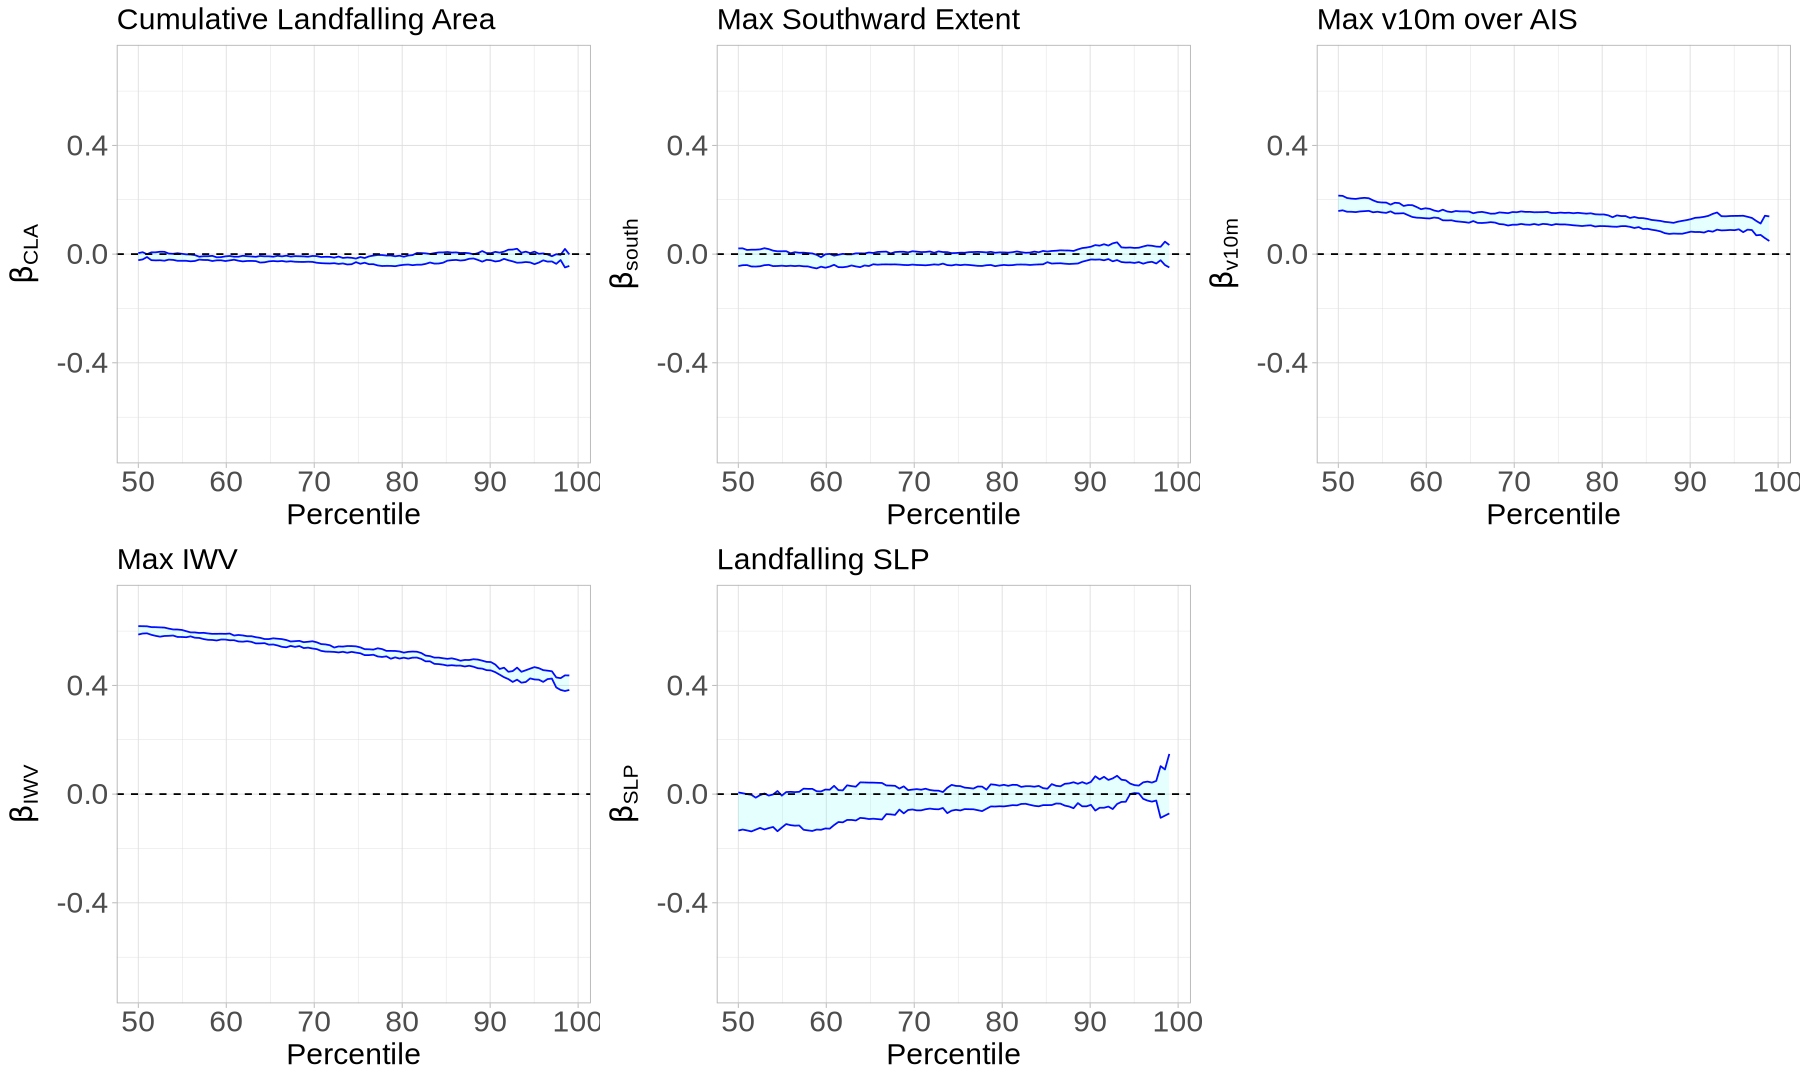

In [57]:
options(repr.plot.width=15, repr.plot.height=9)
p = cowplot::plot_grid(cla_plt, south_plt, v10m_plt, iwv_plt, slp_plt,
                   ncol = 3)
#ggsave('~/isolines_uq/plots/karachi_base_cov_log.png', p, height=7, width=21)
p

### Cumulative Snowfall Results

In [22]:
n_taus <- 100
alpha <- 0.05
taus <- seq(0.5, 0.99, length.out=n_taus)
ci_lowers <- vector(mode='list', length = n_taus)
ci_uppers <- vector(mode='list', length = n_taus)
for (i in 1:length(taus)) {
    
    tau <- taus[i]
    qr_fit <- rq(cumulative_snowfall_ais ~ cumulative_landfalling_area + max_south_extent + max_V10m_ais + max_IWV_ais + landfalling_SLP, tau=tau, data=standardized_dataset)
    ses <- summary(qr_fit)$coefficients[,2]
    ests <- summary(qr_fit)$coefficients[,1]
    ci_lowers[[i]] <- ests + qnorm(alpha/2)*ses
    ci_uppers[[i]] <- ests + qnorm(1-(alpha/2))*ses
    
}

ci_lowers <- data.frame(do.call(rbind, ci_lowers))
ci_uppers <- data.frame(do.call(rbind, ci_uppers))

ci_lowers$taus <- taus*100
ci_uppers$taus <- taus*100

full_df <- data.frame(cbind(ci_uppers, ci_lowers))

In [23]:
ylims <- c(-0.7, 0.7)
ax_title_fsize <- 18
axis_fsize <- 18
title_fsize <- 18

cla_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=cumulative_landfalling_area), color='blue') + 
geom_line(aes(x=taus, y=cumulative_landfalling_area.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=cumulative_landfalling_area.1,ymax=cumulative_landfalling_area), fill="cyan", alpha = 0.1) +
#ylim(ylims) + 
geom_hline(yintercept=0, linetype='dashed') + 
xlab('Percentile') + 
ylab(TeX('$\\beta_{CLA}$')) + ggtitle('Cumulative Landfalling Area') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

south_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_south_extent), color='blue') + 
geom_line(aes(x=taus, y=max_south_extent.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_south_extent.1,ymax=max_south_extent), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{south}$')) + ggtitle('Max Southward Extent') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

v10m_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_V10m_ais), color='blue') + 
geom_line(aes(x=taus, y=max_V10m_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_V10m_ais.1,ymax=max_V10m_ais), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{v10m}$')) + ggtitle('Max v10m over AIS') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

iwv_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_IWV_ais), color='blue') + 
geom_line(aes(x=taus, y=max_IWV_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_IWV_ais.1,ymax=max_IWV_ais), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{IWV}$')) + ggtitle('Max IWV') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

slp_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=landfalling_SLP.1), color='blue') + 
geom_line(aes(x=taus, y=landfalling_SLP), color='blue') + 
geom_ribbon(aes(x=taus, ymin=landfalling_SLP.1,ymax=landfalling_SLP), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{SLP}$')) + ggtitle('Landfalling SLP') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))


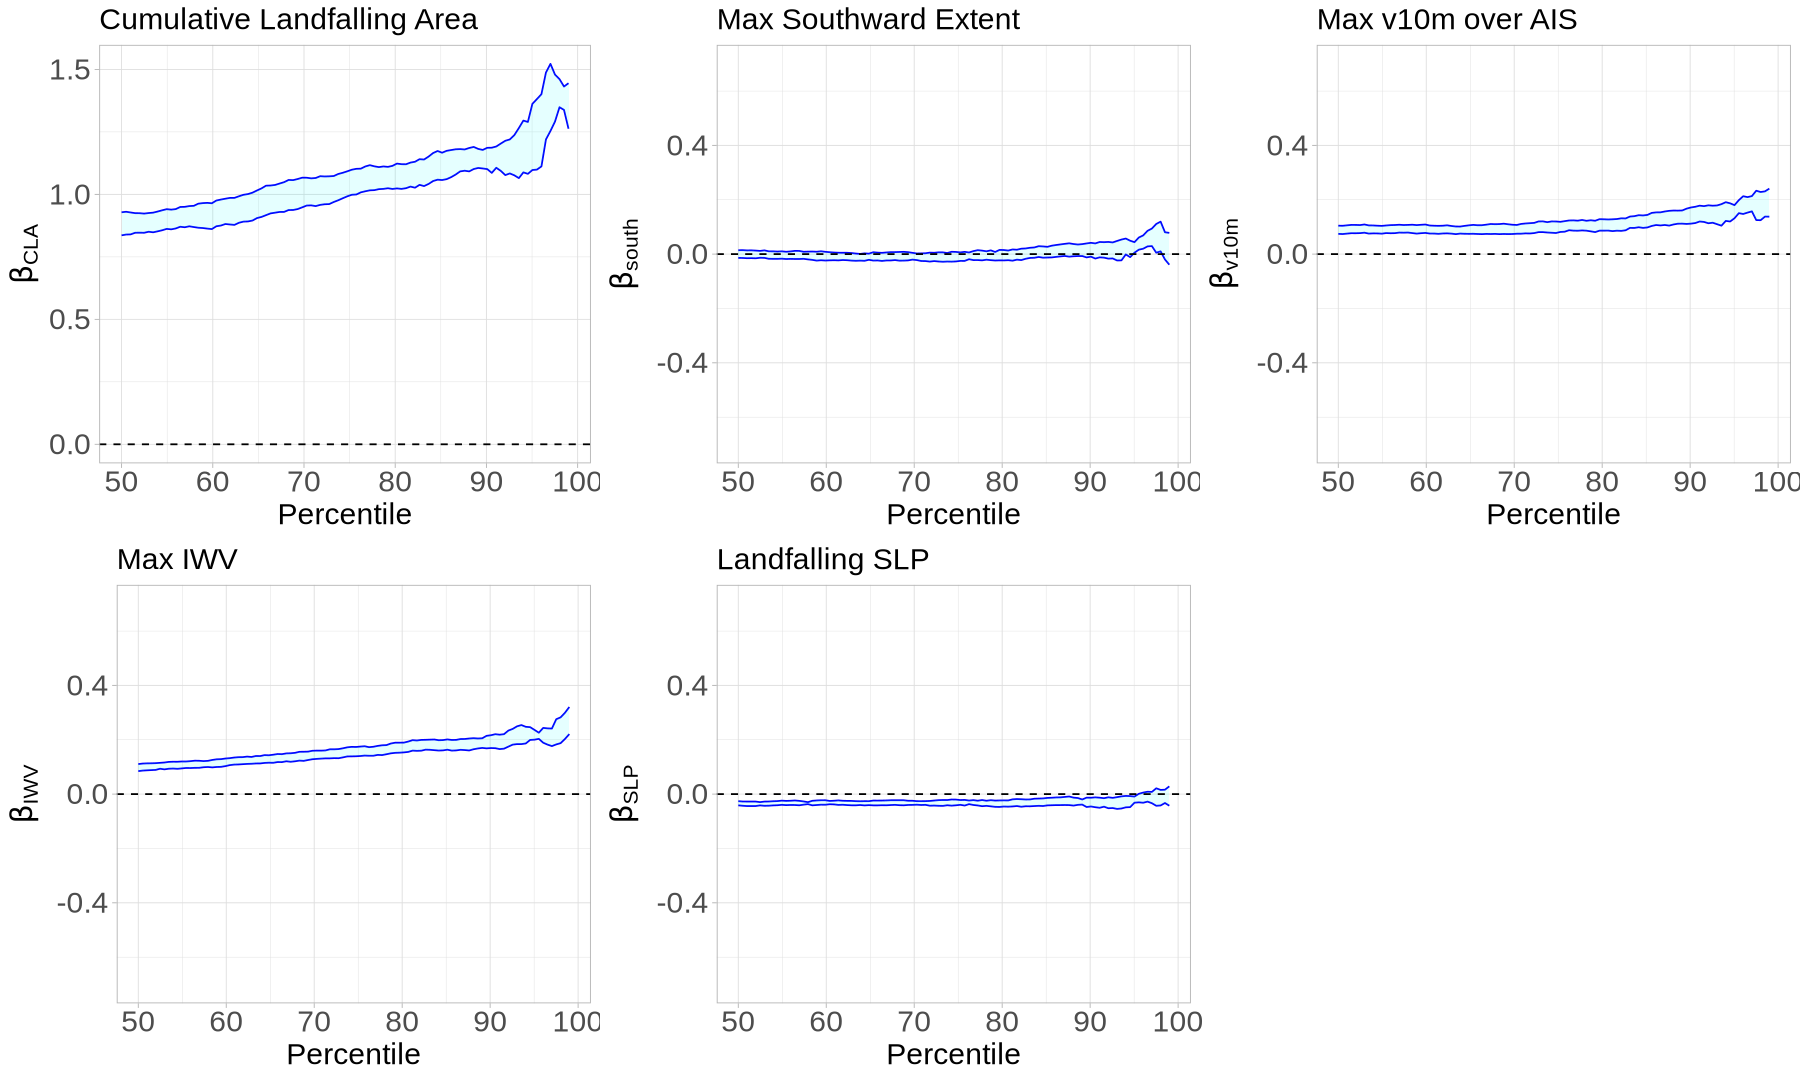

In [24]:
options(repr.plot.width=15, repr.plot.height=9)
p = cowplot::plot_grid(cla_plt, south_plt, v10m_plt, iwv_plt, slp_plt,
                   ncol = 3)
#ggsave('~/isolines_uq/plots/karachi_base_cov_log.png', p, height=7, width=21)
p

### Cumulative Rainfall Results

In [176]:
n_taus <- 100
alpha <- 0.05
taus <- seq(0.5, 0.99, length.out=n_taus)
ci_lowers <- vector(mode='list', length = n_taus)
ci_uppers <- vector(mode='list', length = n_taus)
for (i in 1:length(taus)) {
    
    tau <- taus[i]
    qr_fit <- rq(cumulative_rainfall_ais ~ cumulative_landfalling_area + max_south_extent + max_V10m_ais + max_IWV_ais + landfalling_SLP, tau=tau, data=standardized_dataset)
    ses <- summary(qr_fit)$coefficients[,2]
    ests <- summary(qr_fit)$coefficients[,1]
    ci_lowers[[i]] <- ests + qnorm(alpha/2)*ses
    ci_uppers[[i]] <- ests + qnorm(1-(alpha/2))*ses
    
}

ci_lowers <- data.frame(do.call(rbind, ci_lowers))
ci_uppers <- data.frame(do.call(rbind, ci_uppers))

ci_lowers$taus <- taus*100
ci_uppers$taus <- taus*100

full_df <- data.frame(cbind(ci_uppers, ci_lowers))

In [177]:
ylims <- c(-0.7, 0.7)
ax_title_fsize <- 18
axis_fsize <- 18
title_fsize <- 18

cla_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=cumulative_landfalling_area), color='blue') + 
geom_line(aes(x=taus, y=cumulative_landfalling_area.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=cumulative_landfalling_area.1,ymax=cumulative_landfalling_area), fill="cyan", alpha = 0.1) +
#ylim(ylims) + 
geom_hline(yintercept=0, linetype='dashed') + 
xlab('Percentile') + 
ylab(TeX('$\\beta_{CLA}$')) + ggtitle('Cumulative Landfalling Area') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

south_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_south_extent), color='blue') + 
geom_line(aes(x=taus, y=max_south_extent.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_south_extent.1,ymax=max_south_extent), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{south}$')) + ggtitle('Max Southward Extent') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

v10m_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_V10m_ais), color='blue') + 
geom_line(aes(x=taus, y=max_V10m_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_V10m_ais.1,ymax=max_V10m_ais), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{v10m}$')) + ggtitle('Max v10m over AIS') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

iwv_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_IWV_ais), color='blue') + 
geom_line(aes(x=taus, y=max_IWV_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_IWV_ais.1,ymax=max_IWV_ais), fill="cyan", alpha = 0.1) +
#ylim(ylims) + 
geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{IWV}$')) + ggtitle('Max IWV') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

slp_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=landfalling_SLP.1), color='blue') + 
geom_line(aes(x=taus, y=landfalling_SLP), color='blue') + 
geom_ribbon(aes(x=taus, ymin=landfalling_SLP.1,ymax=landfalling_SLP), fill="cyan", alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{SLP}$')) + ggtitle('Landfalling SLP') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))


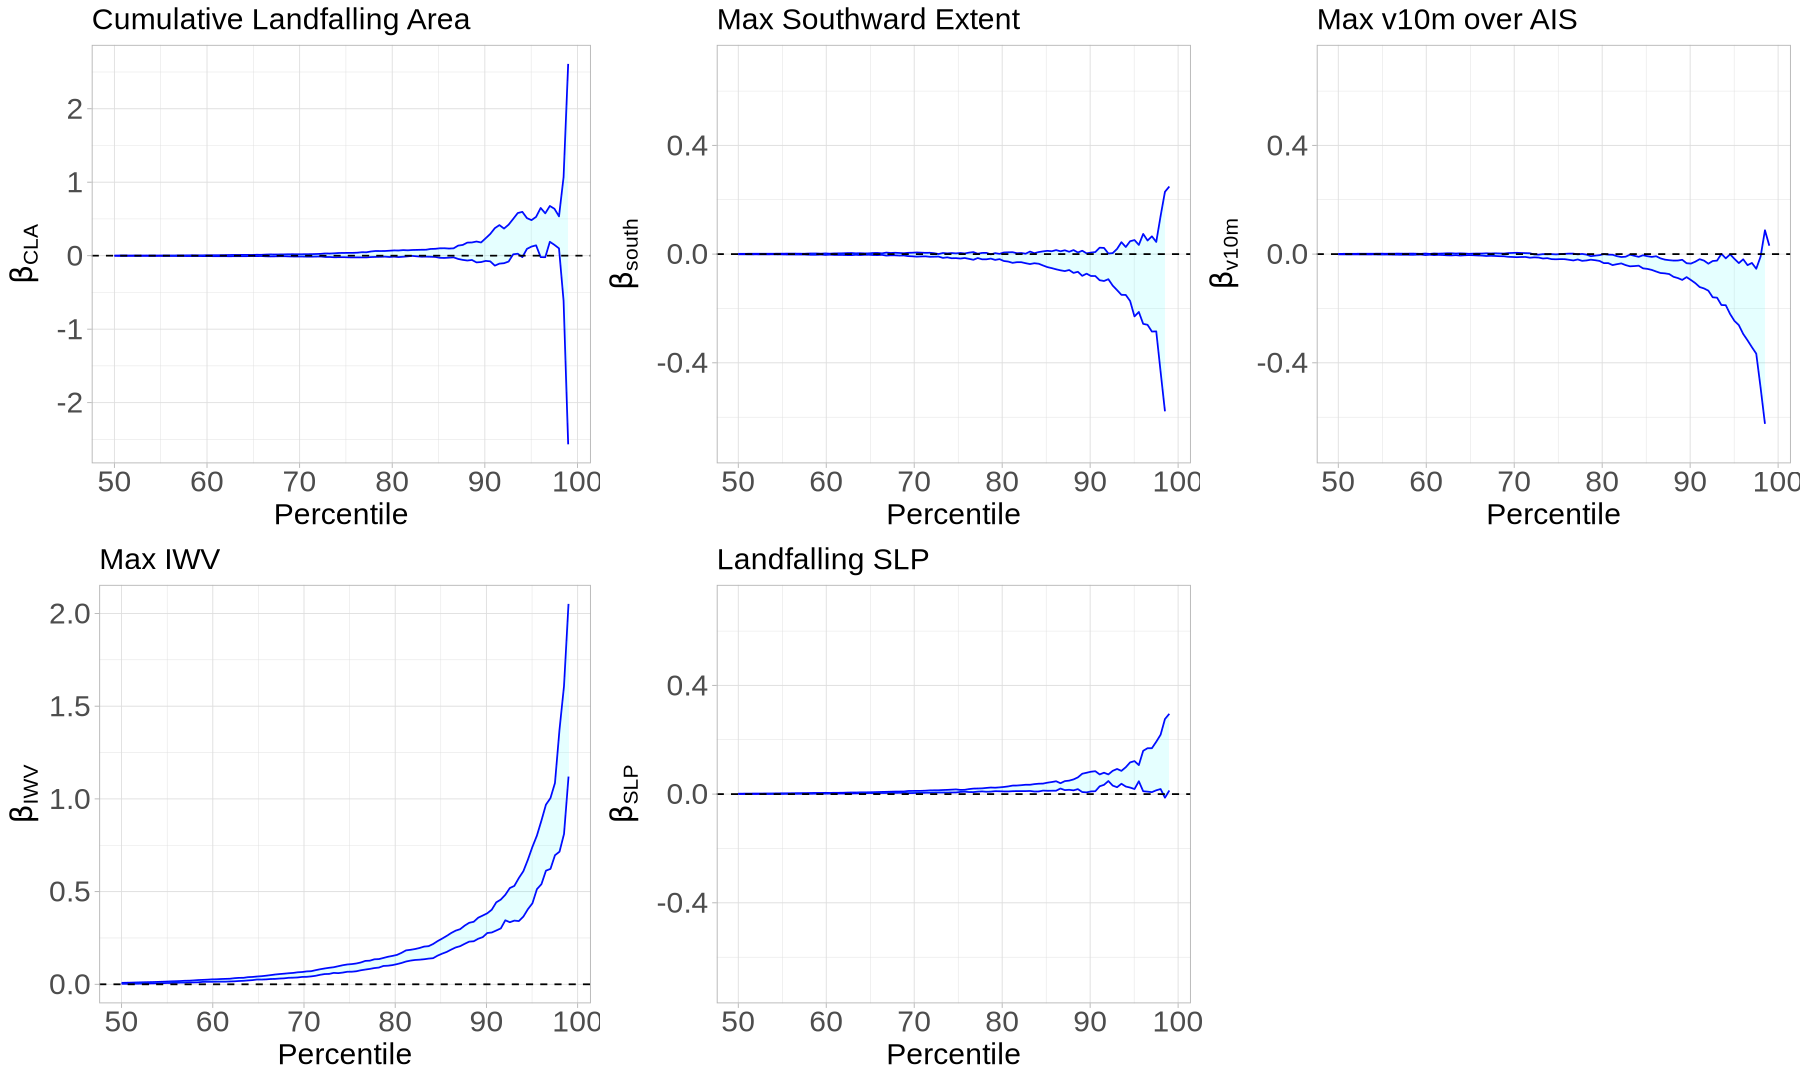

In [178]:
options(repr.plot.width=15, repr.plot.height=9)
p = cowplot::plot_grid(cla_plt, south_plt, v10m_plt, iwv_plt, slp_plt,
                   ncol = 3)
#ggsave('~/isolines_uq/plots/karachi_base_cov_log.png', p, height=7, width=21)
p

## Extremal Quantile Regression

Appears that $0.9$ is the highest quantile for which the dimension-adjusted order is at least 40, which is a good rule-of-thumb according to Chernozhukov to use extremal inference. 

In [25]:
n <- nrow(standardized_dataset)

### 2m-Temperature Anomaly Impacts

In [201]:
n_taus <- 30
alpha <- 0.05
tau_extremes <- seq(0.9, 0.99, length.out=30)
ci_lowers <- vector(mode='list', length = n_taus)
ci_uppers <- vector(mode='list', length = n_taus)
for (i in 1:length(tau_extremes)) {
    
    tau <- tau_extremes[i]
    qr_fit <- rq(max_T2M_anomaly_ais ~ cumulative_landfalling_area + max_south_extent + max_V10m_ais + max_IWV_ais + landfalling_SLP, tau=tau, data=standardized_dataset)
    qr_fit_summary <- summary(qr_fit, se='extreme', alpha=0.05)
    ci_lowers[[i]] <- qr_fit_summary$coefficients[-1,4]
    ci_uppers[[i]] <- qr_fit_summary$coefficients[-1,3]
    
}

ci_lowers <- data.frame(do.call(rbind, ci_lowers))
ci_uppers <- data.frame(do.call(rbind, ci_uppers))

ci_lowers$taus <- tau_extremes*100
ci_uppers$taus <- tau_extremes*100

full_df <- data.frame(cbind(ci_uppers, ci_lowers))

In [209]:
ylims <- c(-3, 3)
ax_title_fsize <- 18
axis_fsize <- 18
title_fsize <- 18
fill <- 'blue'

cla_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=cumulative_landfalling_area), color='blue') + 
geom_line(aes(x=taus, y=cumulative_landfalling_area.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=cumulative_landfalling_area.1,ymax=cumulative_landfalling_area), fill=fill, alpha = 0.1) +
ylim(ylims) + 
geom_hline(yintercept=0, linetype='dashed') + 
xlab('Percentile') + 
ylab(TeX('$\\beta_{CLA}$')) + ggtitle('Cumulative Landfalling Area') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

south_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_south_extent), color='blue') + 
geom_line(aes(x=taus, y=max_south_extent.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_south_extent.1,ymax=max_south_extent), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{south}$')) + ggtitle('Max Southward Extent') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

v10m_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_V10m_ais), color='blue') + 
geom_line(aes(x=taus, y=max_V10m_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_V10m_ais.1,ymax=max_V10m_ais), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{v10m}$')) + ggtitle('Max v10m over AIS') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

iwv_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_IWV_ais), color='blue') + 
geom_line(aes(x=taus, y=max_IWV_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_IWV_ais.1,ymax=max_IWV_ais), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{IWV}$')) + ggtitle('Max IWV') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

slp_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=landfalling_SLP.1), color='blue') + 
geom_line(aes(x=taus, y=landfalling_SLP), color='blue') + 
geom_ribbon(aes(x=taus, ymin=landfalling_SLP.1,ymax=landfalling_SLP), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{SLP}$')) + ggtitle('Landfalling SLP') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))


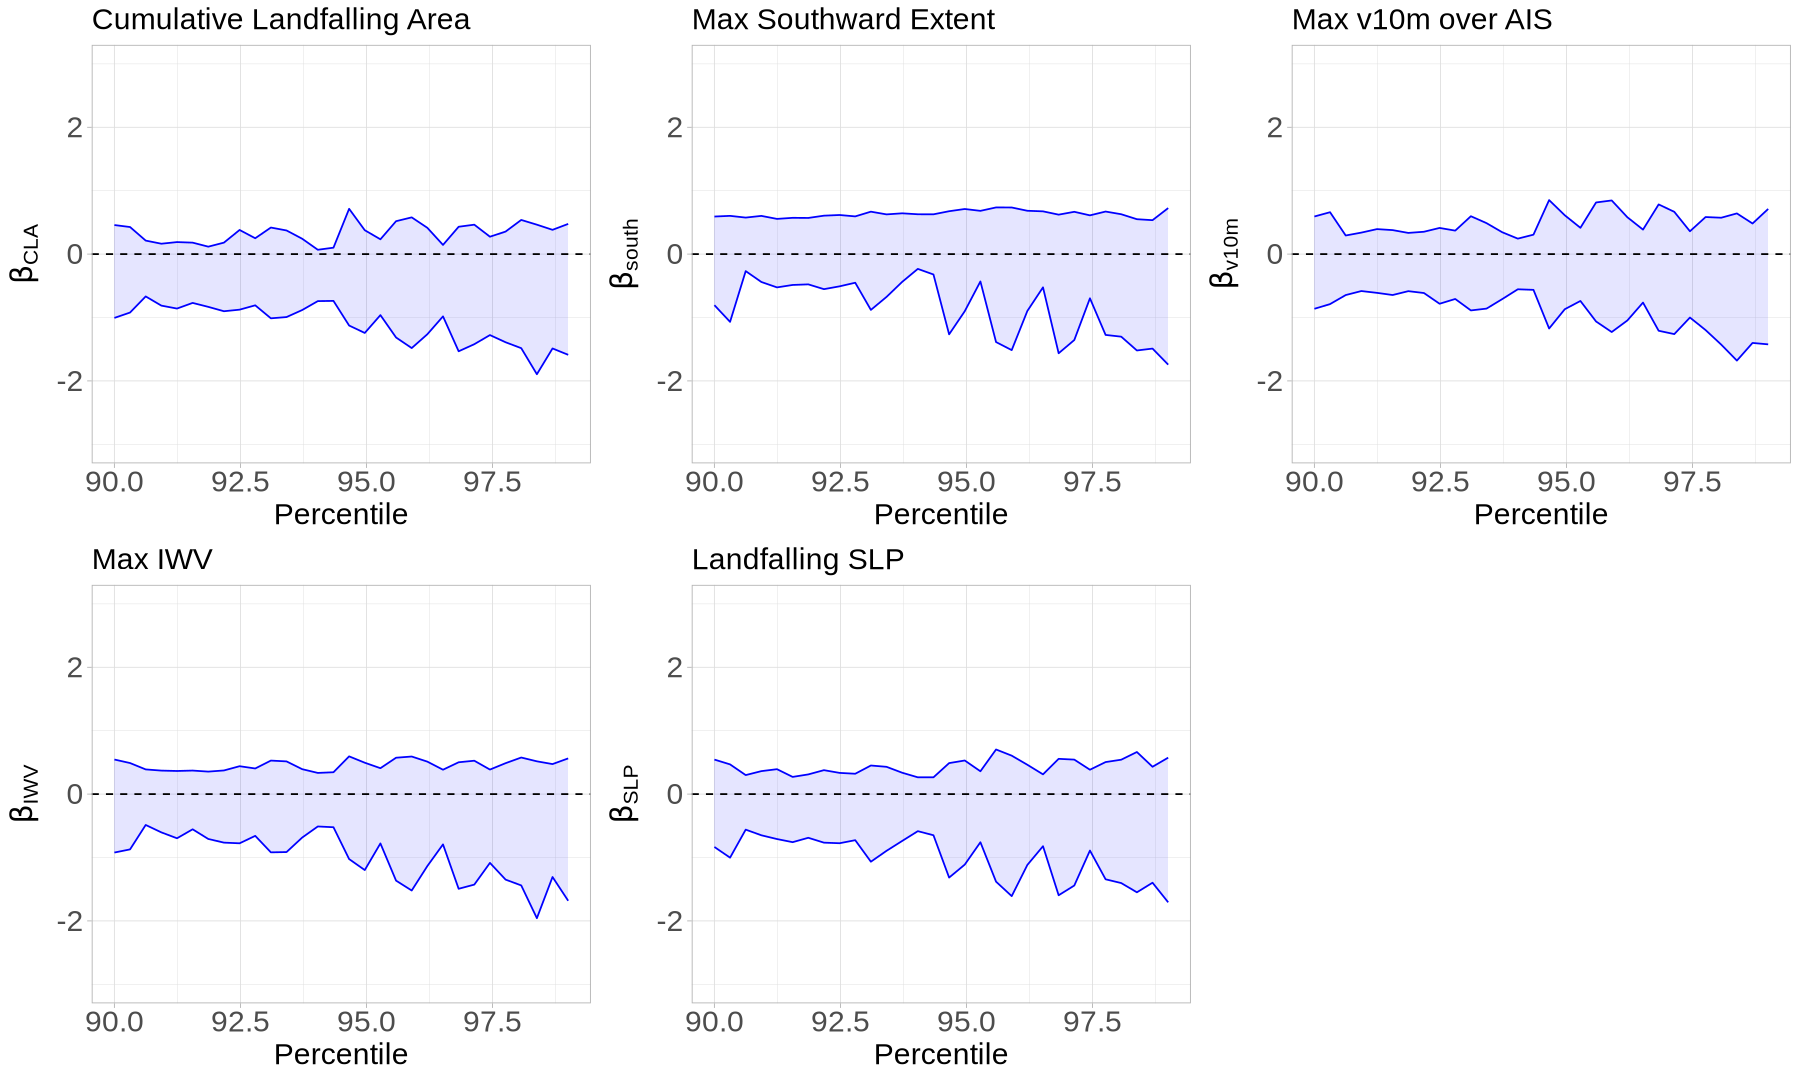

In [210]:
options(repr.plot.width=15, repr.plot.height=9)
p = cowplot::plot_grid(cla_plt, south_plt, v10m_plt, iwv_plt, slp_plt,
                   ncol = 3)
#ggsave('~/isolines_uq/plots/karachi_base_cov_log.png', p, height=7, width=21)
p

### Snowfall Impacts

In [212]:
n_taus <- 30
alpha <- 0.05
tau_extremes <- seq(0.9, 0.99, length.out=30)
ci_lowers <- vector(mode='list', length = n_taus)
ci_uppers <- vector(mode='list', length = n_taus)
for (i in 1:length(tau_extremes)) {
    
    tau <- tau_extremes[i]
    qr_fit <- rq(cumulative_snowfall_ais ~ cumulative_landfalling_area + max_south_extent + max_V10m_ais + max_IWV_ais + landfalling_SLP, tau=tau, data=standardized_dataset)
    qr_fit_summary <- summary(qr_fit, se='extreme', alpha=0.05)
    ci_lowers[[i]] <- qr_fit_summary$coefficients[-1,4]
    ci_uppers[[i]] <- qr_fit_summary$coefficients[-1,3]
    
}

ci_lowers <- data.frame(do.call(rbind, ci_lowers))
ci_uppers <- data.frame(do.call(rbind, ci_uppers))

ci_lowers$taus <- tau_extremes*100
ci_uppers$taus <- tau_extremes*100

full_df <- data.frame(cbind(ci_uppers, ci_lowers))

In [213]:
ylims <- c(-3, 3)
ax_title_fsize <- 18
axis_fsize <- 18
title_fsize <- 18
fill <- 'blue'

cla_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=cumulative_landfalling_area), color='blue') + 
geom_line(aes(x=taus, y=cumulative_landfalling_area.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=cumulative_landfalling_area.1,ymax=cumulative_landfalling_area), fill=fill, alpha = 0.1) +
ylim(ylims) + 
geom_hline(yintercept=0, linetype='dashed') + 
xlab('Percentile') + 
ylab(TeX('$\\beta_{CLA}$')) + ggtitle('Cumulative Landfalling Area') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

south_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_south_extent), color='blue') + 
geom_line(aes(x=taus, y=max_south_extent.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_south_extent.1,ymax=max_south_extent), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{south}$')) + ggtitle('Max Southward Extent') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

v10m_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_V10m_ais), color='blue') + 
geom_line(aes(x=taus, y=max_V10m_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_V10m_ais.1,ymax=max_V10m_ais), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{v10m}$')) + ggtitle('Max v10m over AIS') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

iwv_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_IWV_ais), color='blue') + 
geom_line(aes(x=taus, y=max_IWV_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_IWV_ais.1,ymax=max_IWV_ais), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{IWV}$')) + ggtitle('Max IWV') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

slp_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=landfalling_SLP.1), color='blue') + 
geom_line(aes(x=taus, y=landfalling_SLP), color='blue') + 
geom_ribbon(aes(x=taus, ymin=landfalling_SLP.1,ymax=landfalling_SLP), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{SLP}$')) + ggtitle('Landfalling SLP') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))


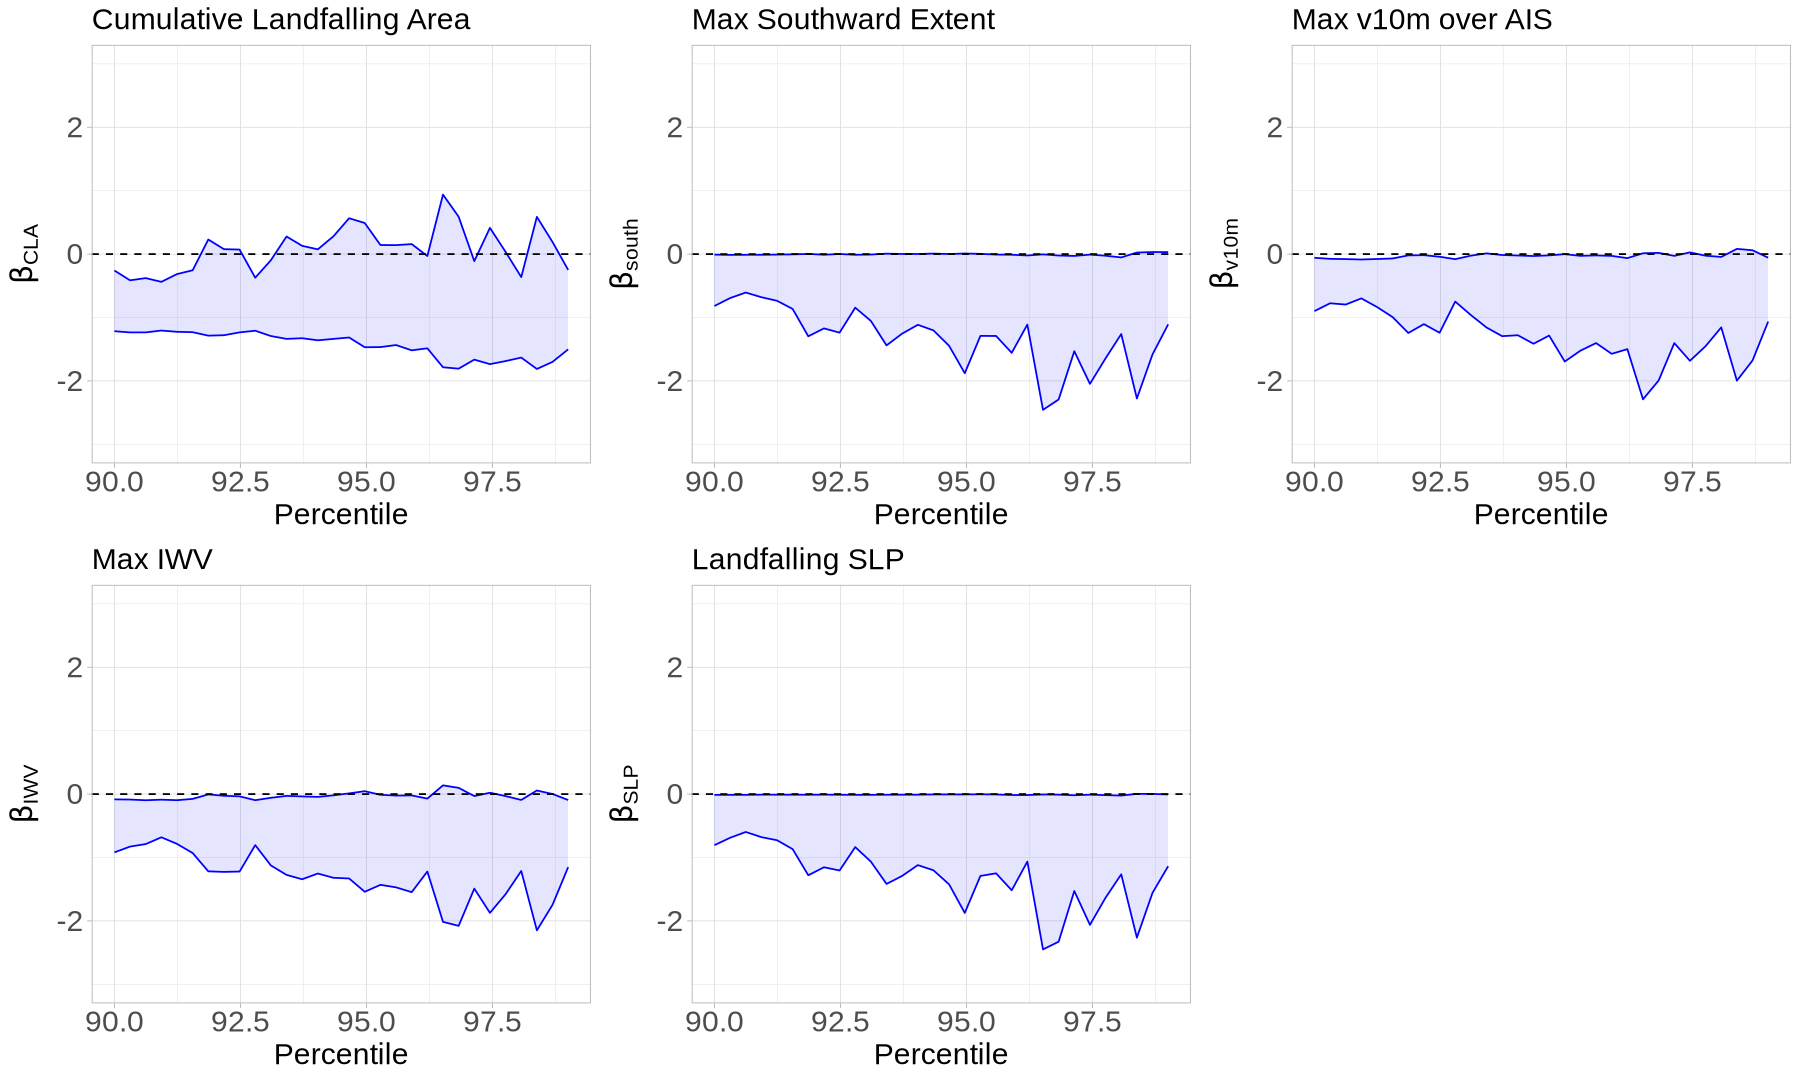

In [214]:
options(repr.plot.width=15, repr.plot.height=9)
p = cowplot::plot_grid(cla_plt, south_plt, v10m_plt, iwv_plt, slp_plt,
                   ncol = 3)
#ggsave('~/isolines_uq/plots/karachi_base_cov_log.png', p, height=7, width=21)
p

### 2m-Temperature Absolute Impacts

In [215]:
n_taus <- 30
alpha <- 0.05
tau_extremes <- seq(0.9, 0.99, length.out=30)
ci_lowers <- vector(mode='list', length = n_taus)
ci_uppers <- vector(mode='list', length = n_taus)
for (i in 1:length(tau_extremes)) {
    
    tau <- tau_extremes[i]
    qr_fit <- rq(max_T2m_ais ~ cumulative_landfalling_area + max_south_extent + max_V10m_ais + max_IWV_ais + landfalling_SLP, tau=tau, data=standardized_dataset)
    qr_fit_summary <- summary(qr_fit, se='extreme', alpha=0.05)
    ci_lowers[[i]] <- qr_fit_summary$coefficients[-1,4]
    ci_uppers[[i]] <- qr_fit_summary$coefficients[-1,3]
    
}

ci_lowers <- data.frame(do.call(rbind, ci_lowers))
ci_uppers <- data.frame(do.call(rbind, ci_uppers))

ci_lowers$taus <- tau_extremes*100
ci_uppers$taus <- tau_extremes*100

full_df <- data.frame(cbind(ci_uppers, ci_lowers))

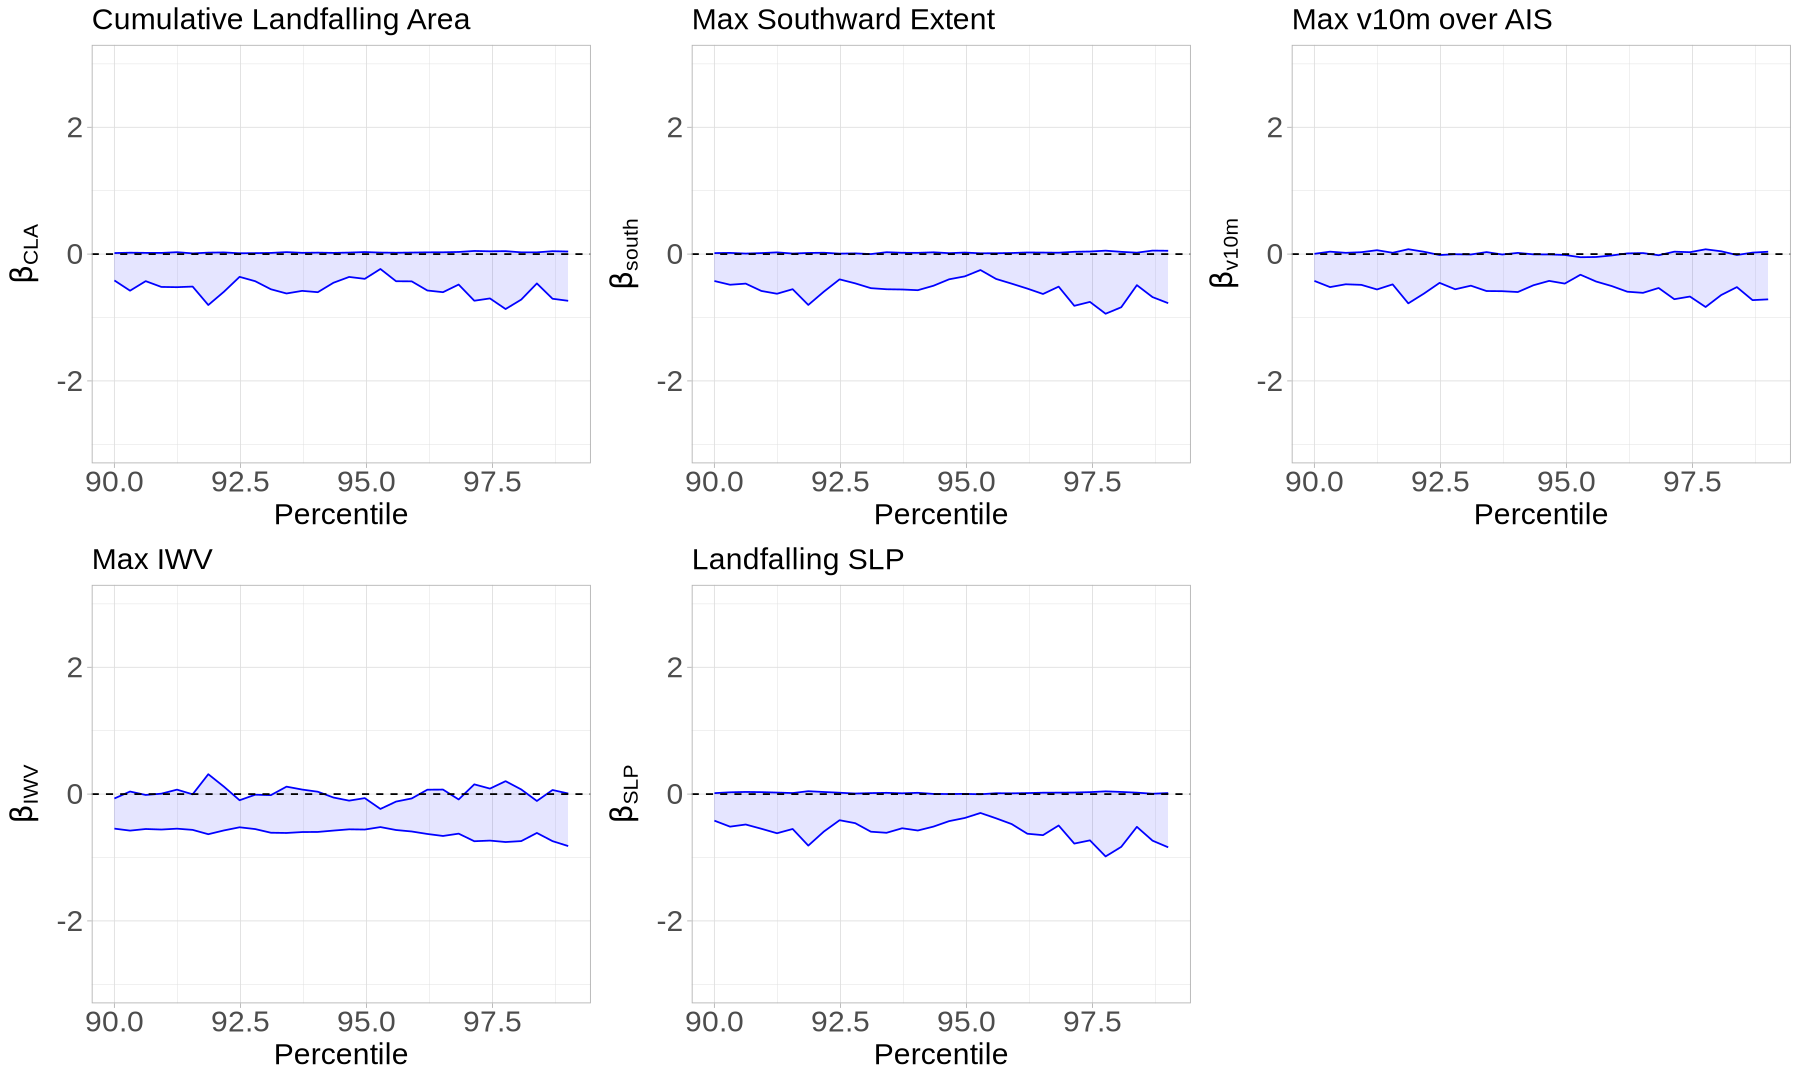

In [216]:
ylims <- c(-3, 3)
ax_title_fsize <- 18
axis_fsize <- 18
title_fsize <- 18
fill <- 'blue'

cla_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=cumulative_landfalling_area), color='blue') + 
geom_line(aes(x=taus, y=cumulative_landfalling_area.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=cumulative_landfalling_area.1,ymax=cumulative_landfalling_area), fill=fill, alpha = 0.1) +
ylim(ylims) + 
geom_hline(yintercept=0, linetype='dashed') + 
xlab('Percentile') + 
ylab(TeX('$\\beta_{CLA}$')) + ggtitle('Cumulative Landfalling Area') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

south_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_south_extent), color='blue') + 
geom_line(aes(x=taus, y=max_south_extent.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_south_extent.1,ymax=max_south_extent), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{south}$')) + ggtitle('Max Southward Extent') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

v10m_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_V10m_ais), color='blue') + 
geom_line(aes(x=taus, y=max_V10m_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_V10m_ais.1,ymax=max_V10m_ais), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{v10m}$')) + ggtitle('Max v10m over AIS') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

iwv_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_IWV_ais), color='blue') + 
geom_line(aes(x=taus, y=max_IWV_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_IWV_ais.1,ymax=max_IWV_ais), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{IWV}$')) + ggtitle('Max IWV') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

slp_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=landfalling_SLP.1), color='blue') + 
geom_line(aes(x=taus, y=landfalling_SLP), color='blue') + 
geom_ribbon(aes(x=taus, ymin=landfalling_SLP.1,ymax=landfalling_SLP), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{SLP}$')) + ggtitle('Landfalling SLP') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

options(repr.plot.width=15, repr.plot.height=9)
p = cowplot::plot_grid(cla_plt, south_plt, v10m_plt, iwv_plt, slp_plt,
                   ncol = 3)
#ggsave('~/isolines_uq/plots/karachi_base_cov_log.png', p, height=7, width=21)
p

#### Cumulative Rainfall Impacts

In [217]:
n_taus <- 30
alpha <- 0.05
tau_extremes <- seq(0.9, 0.99, length.out=30)
ci_lowers <- vector(mode='list', length = n_taus)
ci_uppers <- vector(mode='list', length = n_taus)
for (i in 1:length(tau_extremes)) {
    
    tau <- tau_extremes[i]
    qr_fit <- rq(cumulative_rainfall_ais ~ cumulative_landfalling_area + max_south_extent + max_V10m_ais + max_IWV_ais + landfalling_SLP, tau=tau, data=standardized_dataset)
    qr_fit_summary <- summary(qr_fit, se='extreme', alpha=0.05)
    ci_lowers[[i]] <- qr_fit_summary$coefficients[-1,4]
    ci_uppers[[i]] <- qr_fit_summary$coefficients[-1,3]
    
}

ci_lowers <- data.frame(do.call(rbind, ci_lowers))
ci_uppers <- data.frame(do.call(rbind, ci_uppers))

ci_lowers$taus <- tau_extremes*100
ci_uppers$taus <- tau_extremes*100

full_df <- data.frame(cbind(ci_uppers, ci_lowers))

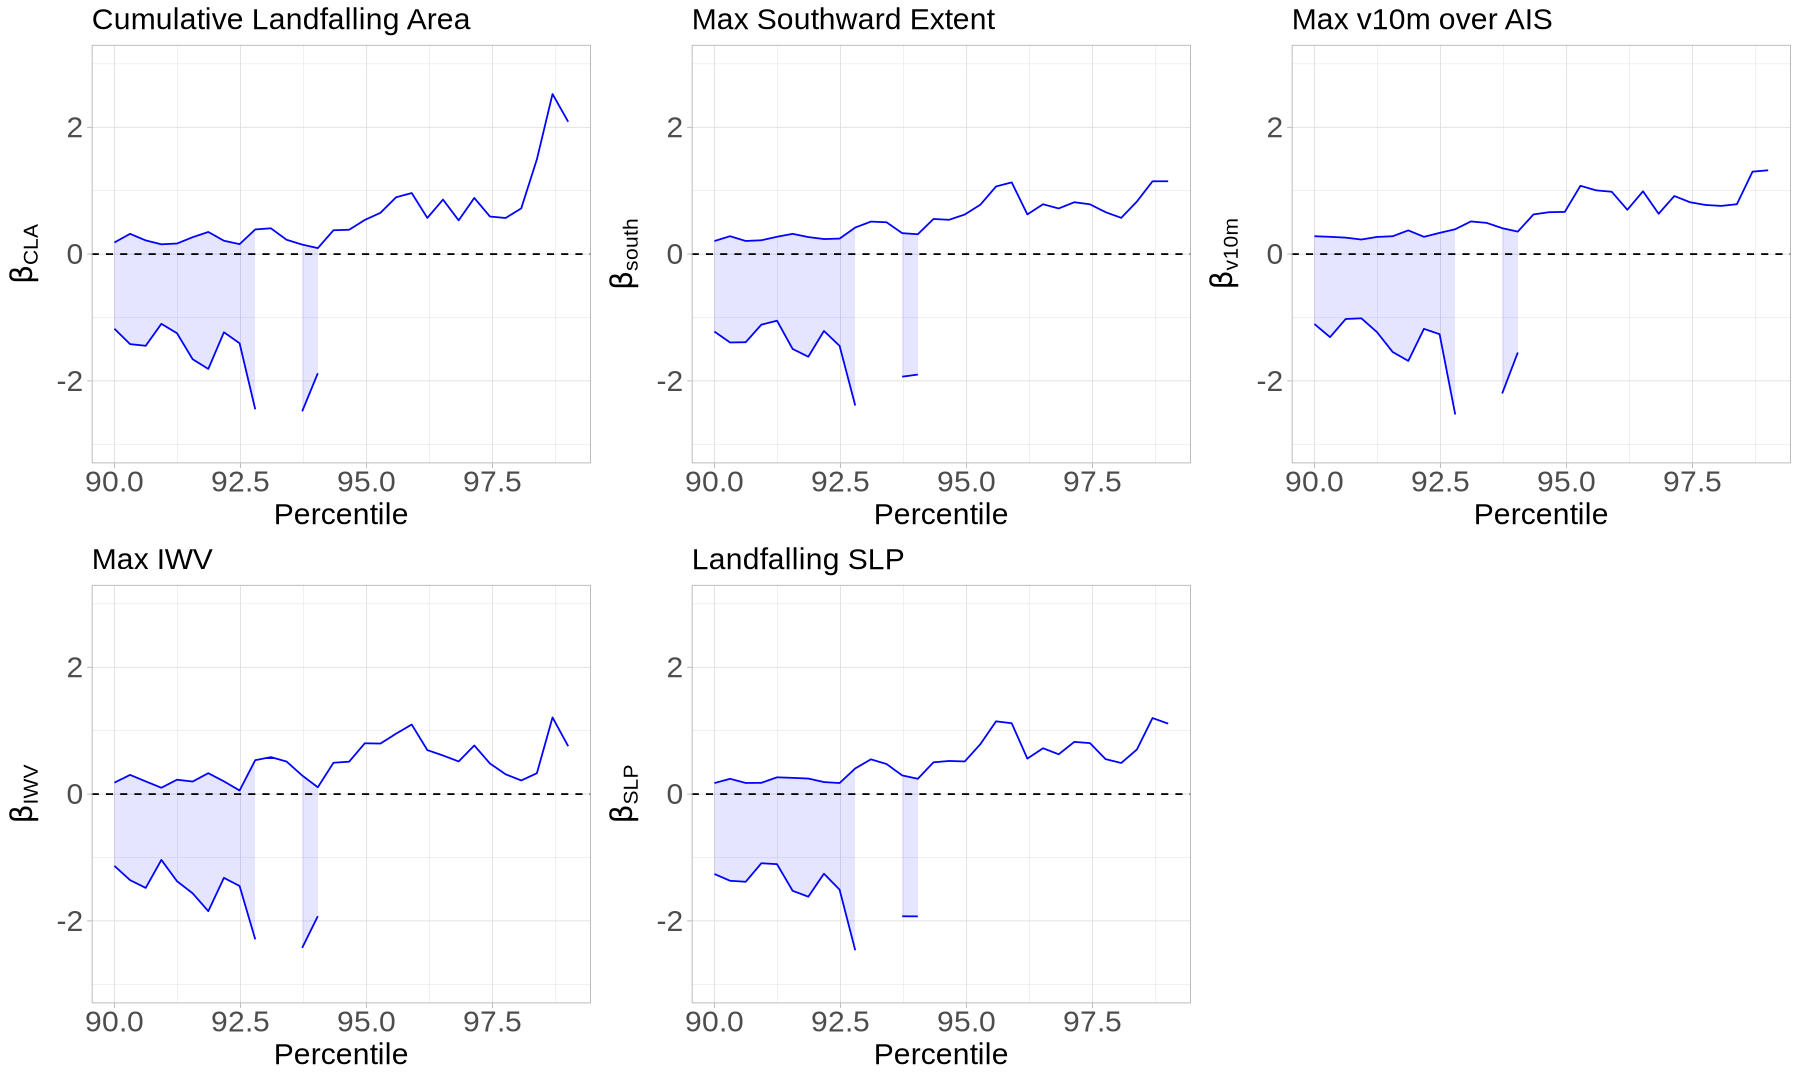

In [218]:
ylims <- c(-3, 3)
ax_title_fsize <- 18
axis_fsize <- 18
title_fsize <- 18
fill <- 'blue'

cla_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=cumulative_landfalling_area), color='blue') + 
geom_line(aes(x=taus, y=cumulative_landfalling_area.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=cumulative_landfalling_area.1,ymax=cumulative_landfalling_area), fill=fill, alpha = 0.1) +
ylim(ylims) + 
geom_hline(yintercept=0, linetype='dashed') + 
xlab('Percentile') + 
ylab(TeX('$\\beta_{CLA}$')) + ggtitle('Cumulative Landfalling Area') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

south_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_south_extent), color='blue') + 
geom_line(aes(x=taus, y=max_south_extent.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_south_extent.1,ymax=max_south_extent), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{south}$')) + ggtitle('Max Southward Extent') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

v10m_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_V10m_ais), color='blue') + 
geom_line(aes(x=taus, y=max_V10m_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_V10m_ais.1,ymax=max_V10m_ais), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{v10m}$')) + ggtitle('Max v10m over AIS') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

iwv_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=max_IWV_ais), color='blue') + 
geom_line(aes(x=taus, y=max_IWV_ais.1), color='blue') + 
geom_ribbon(aes(x=taus, ymin=max_IWV_ais.1,ymax=max_IWV_ais), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{IWV}$')) + ggtitle('Max IWV') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

slp_plt <- ggplot(full_df) + geom_line(aes(x=taus, y=landfalling_SLP.1), color='blue') + 
geom_line(aes(x=taus, y=landfalling_SLP), color='blue') + 
geom_ribbon(aes(x=taus, ymin=landfalling_SLP.1,ymax=landfalling_SLP), fill=fill, alpha = 0.1) +
ylim(ylims) + geom_hline(yintercept=0, linetype='dashed') + xlab('Percentile') + ylab(TeX('$\\beta_{SLP}$')) + ggtitle('Landfalling SLP') + theme_light() +
theme(axis.title = element_text(size = ax_title_fsize), 
      axis.text = element_text(size = axis_fsize),
      text = element_text(size = 20),
      plot.title = element_text(size=title_fsize))

options(repr.plot.width=15, repr.plot.height=9)
p = cowplot::plot_grid(cla_plt, south_plt, v10m_plt, iwv_plt, slp_plt,
                   ncol = 3)
#ggsave('~/isolines_uq/plots/karachi_base_cov_log.png', p, height=7, width=21)
p

## Permutation Tests for the Wet/Windy Precip Problem

#### Snowfall Impacts

In [156]:
moist_and_calm <- standardized_dataset$cumulative_snowfall_ais[(standardized_dataset$max_IWV_ais > 0) & (standardized_dataset$max_V10m_ais < 0)]
labs <- rep(1, length.out=length(moist_and_calm))
moist_and_calm_df <- data.frame(cumulative_snow=moist_and_calm, labs)
dry_and_windy <- standardized_dataset$cumulative_snowfall_ais[(standardized_dataset$max_IWV_ais < 0) & (standardized_dataset$max_V10m_ais > 0)]
labs <- rep(0, length.out=length(dry_and_windy))
dry_and_windy_df <- data.frame(cumulative_snow=dry_and_windy, labs)

full_df <- data.frame(rbind(moist_and_calm_df, dry_and_windy_df))

In [157]:
# a quick permutation test

n_permutations <- 100000
stats_diffs <- rep(NA, n_permutations)

labels <- seq(1, length(tot_storms))

for (i in 1:n_permutations) {
    
    shuffled_labs <- sample(labels)
    full_df$shuffled_labs <- full_df$labs[shuffled_labs]
    stat_moist_and_calm <- mean(full_df$cumulative_snow[full_df$shuffled_labs == 1])
    stat_dry_and_windy <- mean(full_df$cumulative_snow[full_df$shuffled_labs == 0])
    
    
    stats_diffs[i] <- stat_dry_and_windy - stat_moist_and_calm
    
}

In [158]:
obs_diff <- mean(full_df$cumulative_snow[full_df$labs==0]) - mean(full_df$cumulative_snow[full_df$labs==1])

In [159]:
pvalue <- mean(stats_diffs >= obs_diff)
pvalue

[1] 0.00082

#### Rainfall Impacts

In [160]:
moist_and_calm <- standardized_dataset$cumulative_rainfall_ais[(standardized_dataset$max_IWV_ais > 0) & (standardized_dataset$max_V10m_ais < 0)]
labs <- rep(1, length.out=length(moist_and_calm))
moist_and_calm_df <- data.frame(cumulative_rain=moist_and_calm, labs)
dry_and_windy <- standardized_dataset$cumulative_rainfall_ais[(standardized_dataset$max_IWV_ais < 0) & (standardized_dataset$max_V10m_ais > 0)]
labs <- rep(0, length.out=length(dry_and_windy))
dry_and_windy_df <- data.frame(cumulative_rain=dry_and_windy, labs)

full_df <- data.frame(rbind(moist_and_calm_df, dry_and_windy_df))

In [161]:
# a quick permutation test

n_permutations <- 100000
stats_diffs <- rep(NA, n_permutations)

labels <- seq(1, length(tot_storms))

for (i in 1:n_permutations) {
    
    shuffled_labs <- sample(labels)
    full_df$shuffled_labs <- full_df$labs[shuffled_labs]
    stat_moist_and_calm <- mean(full_df$cumulative_rain[full_df$shuffled_labs == 1])
    stat_dry_and_windy <- mean(full_df$cumulative_rain[full_df$shuffled_labs == 0])
    
    
    stats_diffs[i] <- stat_dry_and_windy - stat_moist_and_calm
    
}

In [162]:
obs_diff <- mean(full_df$cumulative_rain[full_df$labs==0]) - mean(full_df$cumulative_rain[full_df$labs==1])
pvalue <- mean(stats_diffs <= obs_diff)
pvalue

[1] 0

#### Temp Anomaly Impacts

In [163]:
moist_and_calm <- standardized_dataset$max_T2M_anomaly_ais[(standardized_dataset$max_IWV_ais > 0) & (standardized_dataset$max_V10m_ais < 0)]
labs <- rep(1, length.out=length(moist_and_calm))
moist_and_calm_df <- data.frame(t2m_anomaly=moist_and_calm, labs)
dry_and_windy <- standardized_dataset$max_T2M_anomaly_ais[(standardized_dataset$max_IWV_ais < 0) & (standardized_dataset$max_V10m_ais > 0)]
labs <- rep(0, length.out=length(dry_and_windy))
dry_and_windy_df <- data.frame(t2m_anomaly=dry_and_windy, labs)

full_df <- data.frame(rbind(moist_and_calm_df, dry_and_windy_df))

In [164]:
# a quick permutation test

n_permutations <- 100000
stats_diffs <- rep(NA, n_permutations)

labels <- seq(1, length(tot_storms))

for (i in 1:n_permutations) {
    
    shuffled_labs <- sample(labels)
    full_df$shuffled_labs <- full_df$labs[shuffled_labs]
    stat_moist_and_calm <- mean(full_df$t2m_anomaly[full_df$shuffled_labs == 1])
    stat_dry_and_windy <- mean(full_df$t2m_anomaly[full_df$shuffled_labs == 0])
    
    
    stats_diffs[i] <- stat_dry_and_windy - stat_moist_and_calm
    
}

In [165]:
obs_diff <- mean(full_df$t2m_anomaly[full_df$labs==0]) - mean(full_df$t2m_anomaly[full_df$labs==1])
pvalue <- mean(stats_diffs >= obs_diff)
pvalue

[1] 0

#### Temp Absolute Impacts

In [166]:
moist_and_calm <- standardized_dataset$max_T2m_ais[(standardized_dataset$max_IWV_ais > 0) & (standardized_dataset$max_V10m_ais < 0)]
labs <- rep(1, length.out=length(moist_and_calm))
moist_and_calm_df <- data.frame(t2m=moist_and_calm, labs)
dry_and_windy <- standardized_dataset$max_T2m_ais[(standardized_dataset$max_IWV_ais < 0) & (standardized_dataset$max_V10m_ais > 0)]
labs <- rep(0, length.out=length(dry_and_windy))
dry_and_windy_df <- data.frame(t2m=dry_and_windy, labs)

full_df <- data.frame(rbind(moist_and_calm_df, dry_and_windy_df))

In [167]:
# a quick permutation test

n_permutations <- 100000
stats_diffs <- rep(NA, n_permutations)

labels <- seq(1, length(tot_storms))

for (i in 1:n_permutations) {
    
    shuffled_labs <- sample(labels)
    full_df$shuffled_labs <- full_df$labs[shuffled_labs]
    stat_moist_and_calm <- mean(full_df$t2m[full_df$shuffled_labs == 1])
    stat_dry_and_windy <- mean(full_df$t2m[full_df$shuffled_labs == 0])
    
    
    stats_diffs[i] <- stat_dry_and_windy - stat_moist_and_calm
    
}

In [168]:
obs_diff <- mean(full_df$t2m[full_df$labs==0]) - mean(full_df$t2m[full_df$labs==1])
pvalue <- mean(stats_diffs <= obs_diff)
pvalue

[1] 0